# Planet Generation Module Testing

Want to write a module that creates the planet files using Python, with different mass functions as options. 

**Needed Mass Functions**
- Log-uniform in a and Mp
- Log-uniform in s and q?
- [Cassan 2012](https://hal.science/tel-01088218/document)
- [Modified Cassan (P19)](https://iopscience.iop.org/article/10.3847/1538-4365/aafb69/pdf)
- [Suzuki 2016](https://iopscience.iop.org/article/10.3847/1538-4357/833/2/145/pdf)
- [Sumi 2023](https://iopscience.iop.org/article/10.3847/1538-3881/ace688/pdf)
- [Zang 2025](https://www.science.org/doi/epdf/10.1126/science.adn6088)

Amber has already worked on the Log-uniform and Sumi mass distributions, so I think I can use those as a guide.

**Needed Variables**
- a run name
- something that feeds it the fields (.sources list, probably)
- number of subruns
- number of planets
- which function to use
- bounds

**Needed Outputs**
- File containing Mp and a or q and s, along with orbital inclination and orbital phase, per simulated event.
- One file per field, per subrun
- Naming convention: {run name}.planets.{field}.{subrun number}

*Maybe it should take a config file like SynthPop?*

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [65]:
srcpath = "/fs/project/gaudi.1/crisp/gulls/starfields/Huston2023_surot2d"
outdir = "testing"

# It seems like all the mass functions use log space, so I'll just do log to start with
m_range = [-2.0, 4.0] # [0.01, 10000.0]
a_range = [-2.0, 2.0] # [0.01, 100]

q_range = [-7.0, -3.0] # [1e-7, 1e-3]
s_range = [-1.0, 1.0] # [0.1, 10.0]

n_pl = 10000 # Number of planets to create per field
n_sr = 3 # Number of subruns that will be done

FIXED_BASE_SEED = None

In [66]:
if FIXED_BASE_SEED is not None:
    local_seed = FIXED_BASE_SEED + field_number * 100003 + file_index
    rng = np.random.default_rng(local_seed)
else:
    rng = np.random.default_rng()

In [67]:
def fields_from_sources(sources_file):
    """Extract integer field identifiers from a sources file.

    Parameters
    ----------
    sources_file : str
        Path to a text file; first whitespace-delimited token per non-empty
        line is interpreted as an integer field number.

    Returns
    -------
    list of int
        Ordered list of parsed field numbers.
    """
    field_numbers = []
    with open(sources_file, 'r') as f:
        for line in f:
            if line.strip():
                field_numbers.append(int(line.split()[0]))
    return field_numbers

In [68]:
srclist = f"{srcpath}/gulls_surot2d_H2023.sources"
fields = fields_from_sources(srclist)
# print(fields)

In [69]:
def orbital_inclination(num_planets):
    # Isotropic inclination (signed degrees)
    rnd = rng.random(num_planets)
    arccos_arg = np.where(rnd < 0.5, 2 * rnd, 2 - 2 * rnd)
    safe_arg = np.clip(arccos_arg, -1.0, 1.0)
    angle = np.arccos(safe_arg)
    signed_angle = np.where(rnd < 0.5, angle, -angle)
    inc_array = 180 * signed_angle / np.pi
    return inc_array

In [70]:
def orbital_phase(num_planets):
    # Orbital phase (deg)
    p_array = 360.0 * rng.random(nl)
    return p_array

## Plot Mass Functions for Reference

In [78]:
def plot_cassan(ax, mmin=0.01, mmax=10.0, stepsize=0.01, in_log=False, **kwargs):
    masses = np.arange(mmin, mmax+stepsize, stepsize)  
    occ_rate = 0.24*(masses/95.0)**-0.73
    
    if in_log:
        ax.plot(np.log10(masses), occ_rate, **kwargs)
        ax.axvline(np.log10(5.2), ls='--', lw=1, c='r', label='Break')
    else:
        ax.plot(masses, occ_rate, **kwargs)
        ax.axvline(5.2, ls='--', lw=1, c='r', label='Break')
        
    return

In [120]:
def plot_mod_cassan(ax, mmin=0.01, mmax=10.0, stepsize=0.01, in_log=False, **kwargs):
    masses = np.arange(mmin, mmax+stepsize, stepsize)
    occ_rate = np.empty_like(masses, dtype=float)
    
    mask = masses < 5.2
    occ_rate[mask] = 2
    occ_rate[~mask] = 0.24*(masses[~mask]/95.0)**-0.73
    
    if in_log:
        ax.plot(np.log10(masses), occ_rate, **kwargs)
        ax.axvline(np.log10(5.2), ls='--', lw=1, c='r', label='Break')
    else:
        ax.plot(masses, 10**occ_rate, **kwargs)
        ax.axvline(5.2, ls='--', lw=1, c='r', label='Break')
        
    return

In [140]:
stepsize=1e-6
masses = np.arange(1e-7, 120+stepsize, stepsize)
occ_rate = np.empty_like(masses, dtype=float)

In [141]:
log_mbreak = -5.27
mbreak = 10**log_mbreak

mask1 = masses >= 0.86
mask2 = (masses < 0.86) & (masses >= 0.08)
mask3 = (masses < 0.08) & (masses >= 0.02)
mask4 = (masses < 0.02) & (masses >= mbreak)
mask5 = masses < mbreak

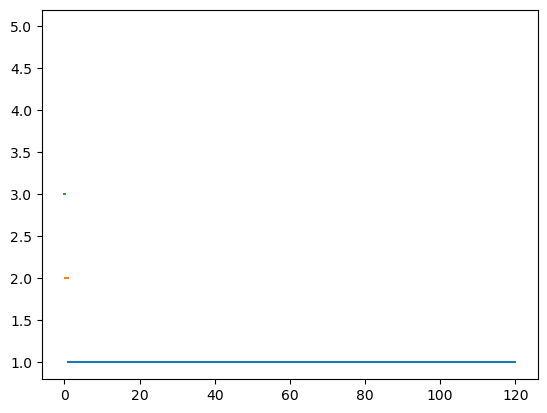

In [144]:
fig, ax = plt.subplots()
ax.plot([masses[mask1][0], masses[mask1][-1]], [1,1])
ax.plot([masses[mask2][0], masses[mask2][-1]], [2,2])
ax.plot([masses[mask3][0], masses[mask3][-1]], [3,3])
ax.plot([masses[mask4][0], masses[mask4][-1]], [4,4])
ax.plot([masses[mask5][0], masses[mask5][-1]], [5,5])

In [121]:
def plot_sumi(ax, mmin=1e-7, mmax=120.0, stepsize=1e-7, in_log=False, **kwargs):
    masses = np.arange(mmin, mmax+stepsize, stepsize)
    occ_rate = np.empty_like(masses, dtype=float)
    
    mask1 = ((masses))
    return

In [122]:
def plot_suzuki(ax, qmin=1e-7, qmax=1e-3, s=1, stepsize=1e-7, in_log=False, q_fixed=True, **kwargs):
    if q_fixed:
        A = 0.61
        qb = 1.7e-4
        n = -0.92
        p = 0.44
        m = 0.50
    else:
        A = 0.62
        qb = 1.65e-4
        n = -0.92
        p = 0.47
        m = 0.50        
        
    qs = np.arange(qmin, qmax+stepsize, stepsize)
    occ_rate = np.empty_like(qs, dtype=float)
    
    mask = qs < qb
    occ_rate[mask] = A * (qs[mask]/qb)**p * s**m
    occ_rate[~mask] = A * (qs[~mask]/qb)**n * s**m
    
    if in_log:
        ax.plot(np.log10(qs), np.log10(occ_rate), **kwargs)
        ax.axvline(np.log10(qb), ls='--', lw=1, c='r', label='Break')
    else:
        ax.plot(qs, occ_rate, **kwargs)
        ax.axvline(qb, ls='--', lw=1, c='r', label='Break')
    
    return

In [123]:
def plot_zang(ax, qmin=1e-7, qmax=1e-3, stepsize=1e-7, in_log=False, **kwargs):
    qs = np.arange(qmin, qmax+stepsize, stepsize)
    occ_rate = 0.18*(qs/1e-4)**(-0.55)
    
    if in_log:
        ax.plot(np.log10(qs), np.log10(occ_rate), **kwargs)
    else:
        ax.plot(qs, occ_rate, **kwargs)
    return

Text(0.5, 0, '$q$')

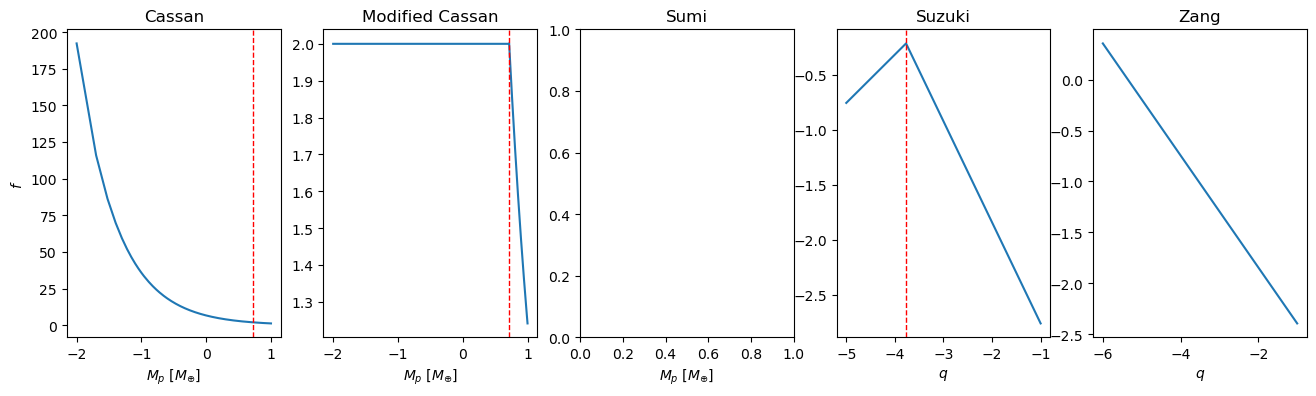

In [129]:
fig, axs = plt.subplots(1, 5, figsize=(16,4))
axs[0].set_title('Cassan')
plot_cassan(axs[0], in_log=True)
axs[0].set_xlabel(r'$M_{p}$ [$M_{\oplus}$]')
axs[0].set_ylabel(r'$f$')

axs[1].set_title('Modified Cassan')
plot_mod_cassan(axs[1], in_log=True)
axs[1].set_xlabel(r'$M_{p}$ [$M_{\oplus}$]')

axs[2].set_title('Sumi')

axs[2].set_xlabel(r'$M_{p}$ [$M_{\oplus}$]')

axs[3].set_title('Suzuki')
plot_suzuki(axs[3], qmin=1e-5, qmax=0.1, stepsize=1e-6, in_log=True)
axs[3].set_xlabel(r'$q$')

axs[4].set_title('Zang')
plot_zang(axs[4], qmin=1e-6, qmax=0.1, stepsize=1e-7, in_log=True)
axs[4].set_xlabel(r'$q$')

In [130]:
10**-5.27

5.370317963702533e-06

## Log-Uniform Mp and a

In [71]:
def loguni_ma(m_min, m_max, a_min, a_max, num_planets, rand_num_gen):
    m_array = rng.uniform(low=m_min, high=m_max, size=num_planets)
    a_array = rng.uniform(low=a_min, high=a_max, size=num_planets)
    
    return m_array, a_array

In [72]:
test_m, test_a = loguni_ma(*m_range, *a_range, n_pl, rng)

### Validate

Text(0.5, 0, 'log(a)')

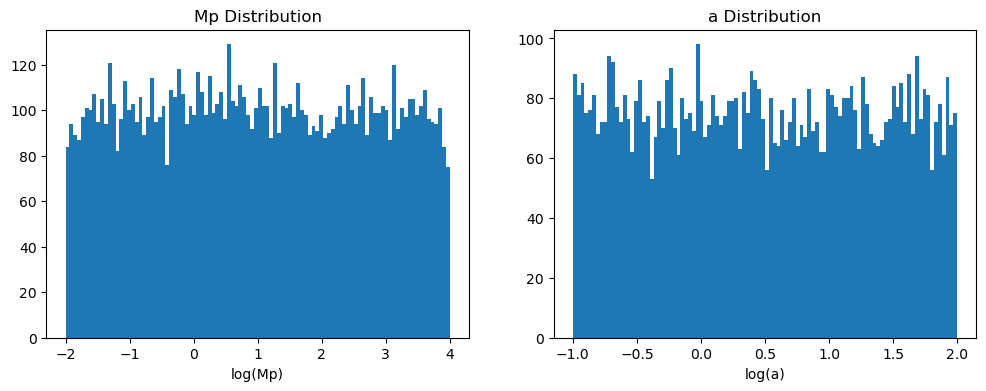

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].set_title('Mp Distribution')
ax[0].hist(test_m, bins=100, range=[-2.0, 4.0])
ax[0].set_xlabel('log(Mp)')

ax[1].set_title('a Distribution')
ax[1].hist(test_a, bins=100, range=[-1.0, 2.0])
ax[1].set_xlabel('log(a)')

## Log-Uniform q and s

In [74]:
def loguni_qs(q_min, q_max, s_min, s_max, num_planets, rand_num_gen):
    q_array = rng.uniform(low=q_min, high=q_max, size=num_planets)
    s_array = rng.uniform(low=s_min, high=s_max, size=num_planets)
    
    return q_array, s_array

In [76]:
test_q, test_s = loguni_qs(*q_range, *s_range, n_pl, rng)

### Validate

Text(0.5, 0, 'log(s)')

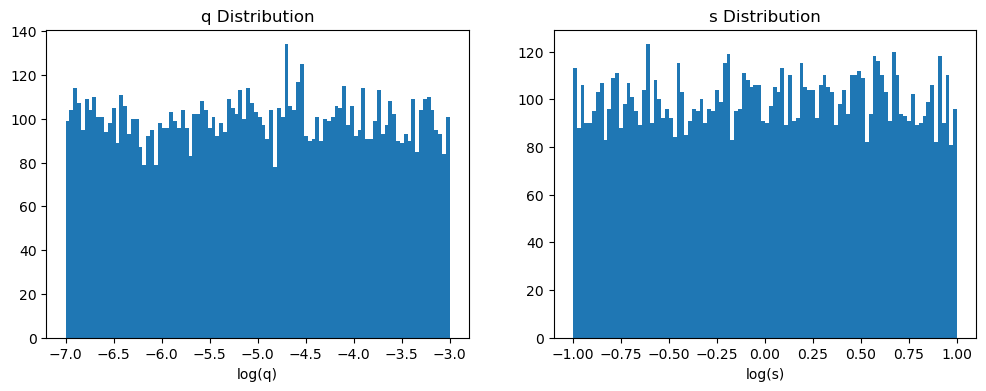

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].set_title('q Distribution')
ax[0].hist(test_q, bins=100, range=[-7.0, -3.0])
ax[0].set_xlabel('log(q)')

ax[1].set_title('s Distribution')
ax[1].hist(test_s, bins=100, range=[-1.0, 1.0])
ax[1].set_xlabel('log(s)')

## Cassan
Don't think I actually want this tbh.

## Modified Cassan

In [61]:
def modified_cassan_ma(m_min, m_max, a_min, a_max, rng, m_break=5.2):
    # written to follow the drawcassan.pl script in GULLS, may be better ways to write
    m_pivot = 95.0 # M_earth
    thresh = 2.0
    slope = -0.73
    pivot_norm = 0.24
    
    
    
    a_array = rng.uniform(low=a_min, high=a_max, size=num_planets)
    return # m, a

## Suzuki

In [62]:
def suzuki_qs(q_min, q_max, s_min, s_max, q_break):
    
    s_array = rng.uniform(low=s_min, high=s_max, size=num_planets)
    return # q, s

## Sumi

In [63]:
def sumi_ma(m_min, m_max, a_min, a_max): # ALL THE OTHER VARIABLES
    
    a_array = rng.uniform(low=a_min, high=a_max, size=num_planets)
    return # m, a

## Zang

In [64]:
def zang_qs(q_min, q_max, s_min, s_max):
    
    s_array = rng.uniform(low=s_min, high=s_max, size=num_planets)
    return # q, s

## Output

Regardless of which mass function is used, we'll need a function or something that puts the Mp or q, a or s, inclination, and orbital phase together. I think this could be something as simple as a pandas dataframe list(zip(\[drawn variables\])) call. The only complication is having it work for multiple subruns + fields, but that needs to be addressed for the whole process. For now I'm just trying to get the mass functions themselves running.